# **Lag features prediction with RF**

## Pre-procseeing lag_features

In [73]:
import numpy as np, pandas as pd
from feature_engine.timeseries.forecasting import LagFeatures

In [74]:
# Ope the preprocessed data
df = pd.read_csv('../data/cleaned_WHT_seeing_data.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,windspeed,airtemperature,relativehumidity,year,month,day,hour,minute,Seeing
0,12.919399,7.173338,35.522750,2020,1,31,19,10,-0.238520
1,13.455912,7.151790,36.587790,2020,1,31,19,20,0.030923
2,16.018960,7.253796,34.251087,2020,1,31,19,30,0.261599
3,15.579474,7.402426,33.061800,2020,1,31,19,40,0.308435
4,16.778657,7.355480,33.812690,2020,1,31,19,50,0.373899


In [75]:
# Creating timestamp
temp_cols = ['year', 'month', 'day', 'hour', 'minute']
df['timestamp'] = pd.to_datetime(df[temp_cols])

# Order by time and use timestamp as index
df_sorted = df.sort_values('timestamp').copy()
df_sorted.index = df_sorted['timestamp']

# Define nights as shifts: 17:00 (D) → 08:00 (D+1)
ts = df_sorted['timestamp']
hours = ts.dt.hour

# Nighttime mask: only 17:00–23:50 and 00:00–07:50
is_night = (hours >= 17) | (hours < 8)

# Base date at midnight of the calendar day
night_date = ts.dt.normalize()

# For times before 08:00, assign them to the previous calendar day
night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)

# Drop daytime rows and keep only real nights
night_date[~is_night] = pd.NaT

# Final night_id as a datetime (one per shift)
df_sorted['night_id'] = night_date

# Optionally, keep only nighttime rows going forward
df_sorted = df_sorted[is_night].copy()

df_sorted.head()

/tmp/ipykernel_39044/2217447232.py:20: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)
/tmp/ipykernel_39044/2217447232.py:20: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[hours < 8] = night_date[hours < 8] - pd.Timedelta(days=1)
/tmp/ipykernel_39044/2217447232.py:23: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[~is_night] = pd.NaT
/tmp/ipykernel_39044/2217447232.py:23: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  night_date[~is_night] = pd.NaT


,windspeed,airtemperature,relativehumidity,year,month,day,hour,minute,Seeing,timestamp,night_id
timestamp,,,,,,,,,,,
2020-01-31 19:10:00,12.919399,7.173338,35.522750,2020,1,31,19,10,-0.238520,2020-01-31 19:10:00,2020-01-31
2020-01-31 19:20:00,13.455912,7.151790,36.587790,2020,1,31,19,20,0.030923,2020-01-31 19:20:00,2020-01-31
2020-01-31 19:30:00,16.018960,7.253796,34.251087,2020,1,31,19,30,0.261599,2020-01-31 19:30:00,2020-01-31
2020-01-31 19:40:00,15.579474,7.402426,33.061800,2020,1,31,19,40,0.308435,2020-01-31 19:40:00,2020-01-31
2020-01-31 19:50:00,16.778657,7.355480,33.812690,2020,1,31,19,50,0.373899,2020-01-31 19:50:00,2020-01-31


In [76]:
# Creating a function to convert minutes, hours, days, and months into sine and cosine functions to preserve
# their cyclic nature
def convert_temp_feat(data, feature, period):
    if feature == 'day':
        dt = pd.to_datetime(dict(
            year=data["year"],
            month=data["month"],
            day=data["day"],
            hour=data["hour"],
            minute=data["minute"],
        ), errors="coerce")

        # Annual seasonality (handles varying month lengths + leap years)
        doy = dt.dt.dayofyear
        year_len = 365.2425
        data["doy_sin"] = np.sin(2 * np.pi * (doy / year_len))
        data["doy_cos"] = np.cos(2 * np.pi * (doy / year_len))
        data.drop('day', axis=1, inplace=True)
    else:
        data[feature + '_sin'] = np.sin(2 * np.pi * data[feature] / period)
        data[feature + '_cos'] = np.cos(2 * np.pi * data[feature] / period)
        data.drop(feature, axis=1, inplace=True)
    return data

# Apply cyclic encodings for time-related features
df_sorted = convert_temp_feat(df_sorted, 'day', None)
df_sorted = convert_temp_feat(df_sorted, 'minute', 60)
df_sorted = convert_temp_feat(df_sorted, 'hour', 24)
df_sorted = convert_temp_feat(df_sorted, 'month', 12)

df_sorted.head()

,windspeed,airtemperature,relativehumidity,year,Seeing,timestamp,night_id,doy_sin,doy_cos,minute_sin,minute_cos,hour_sin,hour_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,,
2020-01-31 19:10:00,12.919399,7.173338,35.522750,2020,-0.238520,2020-01-31 19:10:00,2020-01-31,0.508366,0.861141,8.660254e-01,0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:20:00,13.455912,7.151790,36.587790,2020,0.030923,2020-01-31 19:20:00,2020-01-31,0.508366,0.861141,8.660254e-01,-0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:30:00,16.018960,7.253796,34.251087,2020,0.261599,2020-01-31 19:30:00,2020-01-31,0.508366,0.861141,5.665539e-16,-1.0,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:40:00,15.579474,7.402426,33.061800,2020,0.308435,2020-01-31 19:40:00,2020-01-31,0.508366,0.861141,-8.660254e-01,-0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:50:00,16.778657,7.355480,33.812690,2020,0.373899,2020-01-31 19:50:00,2020-01-31,0.508366,0.861141,-8.660254e-01,0.5,-0.965926,0.258819,0.5,0.866025


In [77]:
# Assigning features and target
# We'll keep the current meteorological + time features as baseline predictors
X_base = df_sorted.drop(columns=['Seeing'])
y = df_sorted['Seeing']

X_base.head()

,windspeed,airtemperature,relativehumidity,year,timestamp,night_id,doy_sin,doy_cos,minute_sin,minute_cos,hour_sin,hour_cos,month_sin,month_cos
timestamp,,,,,,,,,,,,,,
2020-01-31 19:10:00,12.919399,7.173338,35.522750,2020,2020-01-31 19:10:00,2020-01-31,0.508366,0.861141,8.660254e-01,0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:20:00,13.455912,7.151790,36.587790,2020,2020-01-31 19:20:00,2020-01-31,0.508366,0.861141,8.660254e-01,-0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:30:00,16.018960,7.253796,34.251087,2020,2020-01-31 19:30:00,2020-01-31,0.508366,0.861141,5.665539e-16,-1.0,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:40:00,15.579474,7.402426,33.061800,2020,2020-01-31 19:40:00,2020-01-31,0.508366,0.861141,-8.660254e-01,-0.5,-0.965926,0.258819,0.5,0.866025
2020-01-31 19:50:00,16.778657,7.355480,33.812690,2020,2020-01-31 19:50:00,2020-01-31,0.508366,0.861141,-8.660254e-01,0.5,-0.965926,0.258819,0.5,0.866025


In [78]:
# Create lag features for seeing and meteorological variables
# IMPORTANT: data is sampled every 10 minutes, so shift(1) = 10 minutes.
# To predict the full 17:00→08:00 shift, keep the minimum history small so predictions can start
# right after 17:00 (otherwise the first hours of each night are dropped).

# 10-minute data ⇒ 1 lag = 10 min, 6 lags = 60 min, etc.
lag_periods_seeing = list(range(1, 7))   # 1 hour history (adjust as needed)
lag_periods_exog = list(range(1, 4))     # 30 min history

feature_cols_exog = ['windspeed', 'airtemperature', 'relativehumidity']

# Start from df_sorted, which already has night_id and time encodings
lagged_frames = []

for night, group in df_sorted.groupby('night_id'):
    g = group.copy().sort_index()

    # Seeing lags
    for p in lag_periods_seeing:
        g[f'Seeing_lag_{p}'] = g['Seeing'].shift(p)

    # Exogenous lags
    for col in feature_cols_exog:
        for p in lag_periods_exog:
            g[f'{col}_lag_{p}'] = g[col].shift(p)

    lagged_frames.append(g)

# Concatenate all nights back together
df_lagged = pd.concat(lagged_frames).sort_index()

# Drop rows with any NaN in lagged columns (these correspond to the first few time-steps of each night)
lagged_cols = [c for c in df_lagged.columns if 'lag_' in c]
df_lagged = df_lagged.dropna(subset=lagged_cols)

df_lagged.head()

,windspeed,airtemperature,relativehumidity,year,Seeing,timestamp,night_id,doy_sin,doy_cos,minute_sin,...,Seeing_lag_6,windspeed_lag_1,windspeed_lag_2,windspeed_lag_3,airtemperature_lag_1,airtemperature_lag_2,airtemperature_lag_3,relativehumidity_lag_1,relativehumidity_lag_2,relativehumidity_lag_3
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-31 20:10:00,17.035121,6.983220,37.748150,2020,0.312322,2020-01-31 20:10:00,2020-01-31,0.508366,0.861141,8.660254e-01,...,-0.238520,16.142916,16.778657,15.579474,7.209785,7.355480,7.402426,34.650960,33.812690,33.061800
2020-01-31 20:20:00,17.312124,6.890639,38.655262,2020,0.334487,2020-01-31 20:20:00,2020-01-31,0.508366,0.861141,8.660254e-01,...,0.030923,17.035121,16.142916,16.778657,6.983220,7.209785,7.355480,37.748150,34.650960,33.812690
2020-01-31 20:30:00,17.493463,6.930124,38.854170,2020,0.197399,2020-01-31 20:30:00,2020-01-31,0.508366,0.861141,5.665539e-16,...,0.261599,17.312124,17.035121,16.142916,6.890639,6.983220,7.209785,38.655262,37.748150,34.650960
2020-01-31 20:40:00,15.721132,6.758439,40.992730,2020,0.113140,2020-01-31 20:40:00,2020-01-31,0.508366,0.861141,-8.660254e-01,...,0.308435,17.493463,17.312124,17.035121,6.930124,6.890639,6.983220,38.854170,38.655262,37.748150
2020-01-31 20:50:00,15.252467,6.828065,38.968570,2020,0.226775,2020-01-31 20:50:00,2020-01-31,0.508366,0.861141,-8.660254e-01,...,0.373899,15.721132,17.493463,17.312124,6.758439,6.930124,6.890639,40.992730,38.854170,38.655262


In [79]:
# Define final feature matrix X and target y after lagging
# Drop non-numeric / identifier columns that the RF should not try to model directly
X = df_lagged.drop(columns=['Seeing', 'timestamp', 'night_id'])
y = df_lagged['Seeing']

In [80]:
df_lagged[['Seeing'] + [c for c in df_lagged.columns if 'Seeing_lag_' in c]].head()

,Seeing,Seeing_lag_1,Seeing_lag_2,Seeing_lag_3,Seeing_lag_4,Seeing_lag_5,Seeing_lag_6
timestamp,,,,,,,
2020-01-31 20:10:00,0.312322,0.328088,0.373899,0.308435,0.261599,0.030923,-0.238520
2020-01-31 20:20:00,0.334487,0.312322,0.328088,0.373899,0.308435,0.261599,0.030923
2020-01-31 20:30:00,0.197399,0.334487,0.312322,0.328088,0.373899,0.308435,0.261599
2020-01-31 20:40:00,0.113140,0.197399,0.334487,0.312322,0.328088,0.373899,0.308435
2020-01-31 20:50:00,0.226775,0.113140,0.197399,0.334487,0.312322,0.328088,0.373899


In [81]:
# Split train/validation/test by night_id (no leakage between nights)

# Get unique nights in chronological order
unique_nights = df_lagged['night_id'].sort_values().unique()

n_nights = len(unique_nights)
train_end = int(0.7 * n_nights)
val_end = int(0.85 * n_nights)

train_nights = unique_nights[:train_end]
val_nights = unique_nights[train_end:val_end]
test_nights = unique_nights[val_end:]

train_mask = df_lagged['night_id'].isin(train_nights)
val_mask = df_lagged['night_id'].isin(val_nights)
test_mask = df_lagged['night_id'].isin(test_nights)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

X_train.shape, X_val.shape, X_test.shape

((21559, 27), (5500, 27), (5242, 27))

## Training RandomForest Regressor

In [82]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

# Baseline Random Forest
rf = RandomForestRegressor(
    n_estimators=300,       
    max_depth=None,           # or even 10–15 if performance holds
    min_samples_leaf=1,     # prevents extremely deep/sparse leaves
    max_features=0.5,    # or 0.3–0.5 to reduce split cost
    max_samples=0.7,        # use 70% of samples per tree (if sklearn >= 0.22)
    bootstrap=True,
    n_jobs=4,               # lower parallelism to reduce RAM peaks
    random_state=0
)

rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)

rmse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
r2_val = r2_score(y_val, y_val_pred)

np.sqrt(rmse_val), mae_val, r2_val

(0.1484087573208123, 0.10839099459996851, 0.8793241503865772)

In [83]:
# Hyperparameter tuning with group-aware cross-validation using night_id as group

param_distributions = {
    'n_estimators': [300],
    'max_depth': [None],
    'min_samples_leaf': [1],
    'max_features': [0.5],
    'max_samples': [0.5, 0.6, 0.7],
    'bootstrap': [True]
}

# Use only train+val for tuning, but keep track of groups by night_id
tune_mask = train_mask | val_mask
X_tune = X[tune_mask]
y_tune = y[tune_mask]

# Groups for GroupKFold: night_id as group label
groups = df_lagged.loc[tune_mask, 'night_id']

gkf = GroupKFold(n_splits=5)

rf_base = RandomForestRegressor(n_jobs=4, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=20,
    cv=gkf.split(X_tune, y_tune, groups=groups),
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=4,
    random_state=42,
)

random_search.fit(X_tune, y_tune)

best_rf = random_search.best_estimator_
random_search.best_params_, random_search.best_score_

Fitting 5 folds for each of 3 candidates, totalling 15 fits


/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=20. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/pablo/anaconda3/en

({'n_estimators': 300,
  'min_samples_leaf': 1,
  'max_samples': 0.5,
  'max_features': 0.5,
  'max_depth': None,
  'bootstrap': True},
 -0.15709867460725785)

In [84]:
# Refit best model on full train+val, then evaluate on test

best_rf.fit(X_tune, y_tune)

y_test_pred = best_rf.predict(X_test)

rmse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

np.sqrt(rmse_test), mae_test, r2_test

(0.1588345607055217, 0.1173138566452069, 0.8256370469422945)

In [85]:
import matplotlib.pyplot as plt

# Add predictions back to a copy of df_lagged for analysis
results = df_lagged.copy()
results = results.loc[test_mask].copy()
results['y_true'] = y_test
results['y_pred'] = y_test_pred

# Overall metrics (already computed above): rmse_test, mae_test, r2_test
print(f"Test RMSE: {rmse_test:.3f}")
print(f"Test MAE: {mae_test:.3f}")
print(f"Test R^2:  {r2_test:.3f}")

# Per-night metrics
night_metrics = []
for night, group in results.groupby('night_id'):
    rmse_n = np.sqrt(mean_squared_error(group['y_true'], group['y_pred']))
    mae_n = mean_absolute_error(group['y_true'], group['y_pred'])
    r2_n = r2_score(group['y_true'], group['y_pred'])
    night_metrics.append({'night_id': night, 'rmse': rmse_n, 'mae': mae_n, 'r2': r2_n})

night_metrics_df = pd.DataFrame(night_metrics).sort_values('night_id')
night_metrics_df.head(10)

Test RMSE: 0.025
Test MAE: 0.117
Test R^2:  0.826


,night_id,rmse,mae,r2
0,2023-08-14,0.109458,0.088738,0.322431
1,2023-08-15,0.070028,0.054686,0.537421
2,2023-08-16,0.087510,0.068266,0.456193
3,2023-08-17,0.132833,0.101823,0.709879
4,2023-08-18,0.117781,0.091869,0.657913
5,2023-08-19,0.164706,0.127087,0.822780
6,2023-08-20,0.122732,0.092754,0.818868
7,2023-08-21,0.140904,0.108217,-0.560514
8,2023-08-23,0.090788,0.071208,0.545375
9,2023-08-24,0.084674,0.077620,-0.826728


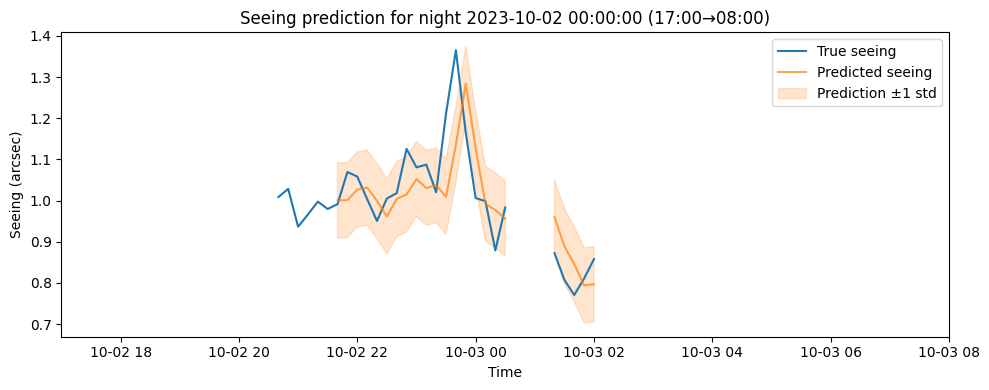

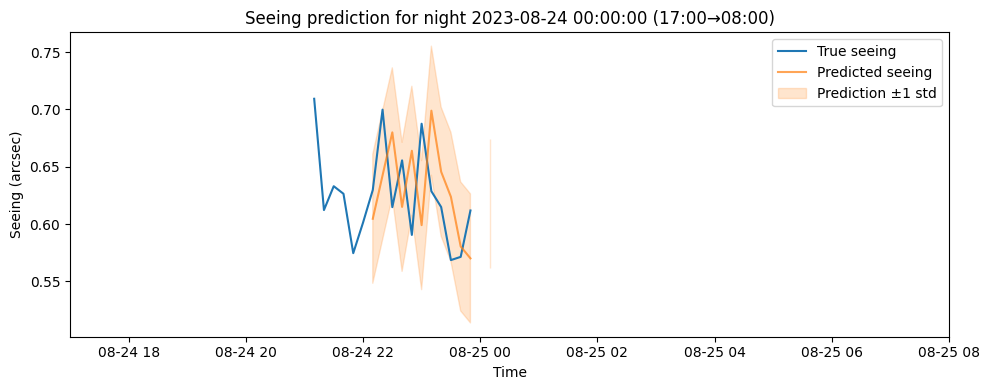

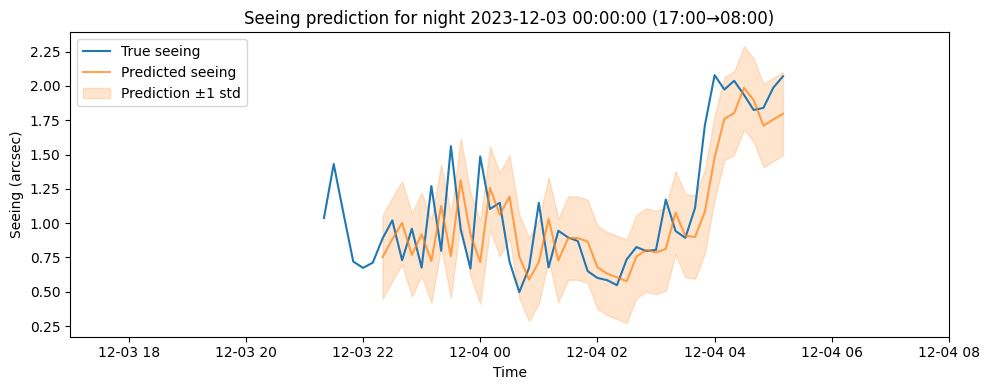

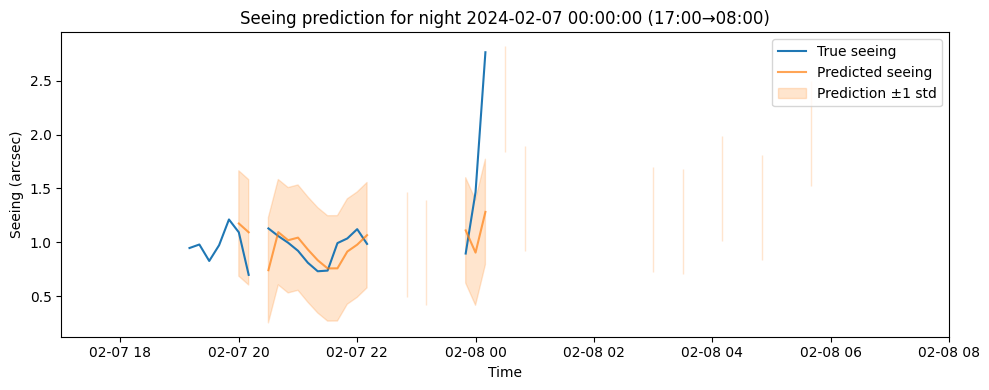

In [86]:
example_nights = night_metrics_df.sort_values('rmse')[4:6]['night_id'].tolist() + \
                 night_metrics_df.sort_values('rmse')[-4:-2]['night_id'].tolist()
example_nights = list(dict.fromkeys(example_nights))  # unique while preserving order

for night in example_nights:
    # Force full-night axis: 17:00 → 08:00 (next day), even if predictions start later
    night_date = pd.to_datetime(night)
    start = night_date + pd.Timedelta(hours=17)
    end = night_date + pd.Timedelta(days=1, hours=8)
    full_idx = pd.date_range(start, end, freq='10min')

    # True seeing for the full night (from df_sorted)
    true_full = df_sorted.loc[start:end, 'Seeing'].reindex(full_idx)

    # Predictions available only where lag-features exist (from results)
    g = results[results['night_id'] == night].copy()
    pred_full = g['y_pred'].reindex(full_idx)

    # Convert to original seeing units
    y_true = np.exp(true_full)
    y_pred = np.exp(pred_full)

    # Errors computed where both exist
    mask = y_true.notna() & y_pred.notna()
    residuals = (y_true[mask] - y_pred[mask])
    err_std = residuals.std()

    plt.figure(figsize=(10, 4))

    plt.plot(full_idx, y_true, label='True seeing')
    plt.plot(full_idx, y_pred, label='Predicted seeing', alpha=0.7)

    # ±1 std band (only where prediction exists)
    plt.fill_between(
        full_idx,
        (y_pred - err_std),
        (y_pred + err_std),
        where=y_pred.notna(),
        interpolate=True,
        color='C1',
        alpha=0.2,
        label='Prediction ±1 std'
    )

    plt.xlim(start, end)
    plt.title(f'Seeing prediction for night {night} (17:00→08:00)')
    plt.xlabel('Time')
    plt.ylabel('Seeing (arcsec)')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [70]:
# Iterative prediction for a full night
# Select a night from the test set for demonstration
#sample_night = night_metrics_df['night_id'][np.argmin(night_metrics_df['rmse'])]  # Night with highest RMSE
sample_night = night_metrics_df['night_id'][13]  # Night with highest RMSE

# Get the actual data for this night from df_sorted (not df_lagged)
sample_night_date = pd.to_datetime(sample_night)
start = sample_night_date + pd.Timedelta(hours=17)
end = sample_night_date + pd.Timedelta(days=1, hours=8)
full_idx = pd.date_range(start, end, freq='10min')

# Get the raw night data from df_sorted (includes all features including Seeing)
night_data_raw = df_sorted.loc[start:end].copy()

# Get the first timestamp that has lag features in df_lagged
night_data_lagged = df_lagged[df_lagged['night_id'] == sample_night].copy()

if len(night_data_lagged) == 0:
    print(f'No lagged data available for night {sample_night}')
    iterative_preds = pd.Series(np.nan, index=full_idx)
else:
    # Get feature columns (exclude target and identifiers)
    feature_cols = [c for c in df_lagged.columns if c not in ['Seeing', 'timestamp', 'night_id']]
    
    # Initialize predictions series
    iterative_preds = pd.Series(np.nan, index=full_idx)
    
    # Start from the first timestamp with lag features
    first_pred_idx = night_data_lagged.index[0]
    
    # Get the lag configuration from the data preparation
    lag_periods_seeing = [1, 2, 3, 4, 5, 6]  # Based on code in cell 7
    lag_periods_exog = [1, 2, 3]
    feature_cols_exog = ['windspeed', 'airtemperature', 'relativehumidity']
    
    # Initialize with actual values for the initial lags
    current_seeing = night_data_raw['Seeing'].copy()
    
    # Iterate through each timestep
    for timestamp in full_idx:
        if timestamp < first_pred_idx:
            continue
        
        # Create feature row for this timestamp
        row_features = {}
        
        # Get base features from night_data_raw (exogenous variables don't change)
        if timestamp in night_data_raw.index:
            base_row = night_data_raw.loc[timestamp]
            for col in feature_cols:
                if 'lag' not in col:
                    if col in base_row.index:
                        row_features[col] = base_row[col]
                    elif col in night_data_raw.columns:
                        row_features[col] = night_data_raw.loc[timestamp, col]
        
        # Calculate lag features
        for p in lag_periods_seeing:
            lag_timestamp = timestamp - pd.Timedelta(minutes=10*p)
            if lag_timestamp in current_seeing.index:
                lag_val = current_seeing.loc[lag_timestamp]
            elif lag_timestamp in iterative_preds.index and not pd.isna(iterative_preds.loc[lag_timestamp]):
                lag_val = iterative_preds.loc[lag_timestamp]
            else:
                lag_val = current_seeing.mean()  # Fallback to mean
            row_features[f'Seeing_lag_{p}'] = lag_val
        
        # Exogenous lags (use actual values)
        for col in feature_cols_exog:
            for p in lag_periods_exog:
                lag_timestamp = timestamp - pd.Timedelta(minutes=10*p)
                if lag_timestamp in night_data_raw.index:
                    row_features[f'{col}_lag_{p}'] = night_data_raw.loc[lag_timestamp, col]
                else:
                    row_features[f'{col}_lag_{p}'] = night_data_raw[col].mean()
        
        # Create feature array in correct order
        X_pred = pd.DataFrame([row_features])
        
        # Ensure all required columns are present
        for col in feature_cols:
            if col not in X_pred.columns:
                X_pred[col] = 0  # Fill missing with 0 or mean
        
        X_pred = X_pred[feature_cols]  # Reorder to match training
        
        # Predict
        pred = best_rf.predict(X_pred)[0]
        iterative_preds.loc[timestamp] = pred
        current_seeing.loc[timestamp] = pred  # Update for next iteration
    
    print(f'Generated {iterative_preds.notna().sum()} iterative predictions')
    print(f'Prediction range: {iterative_preds.min():.3f} to {iterative_preds.max():.3f}')

Generated 60 iterative predictions
Prediction range: 0.027 to 0.149


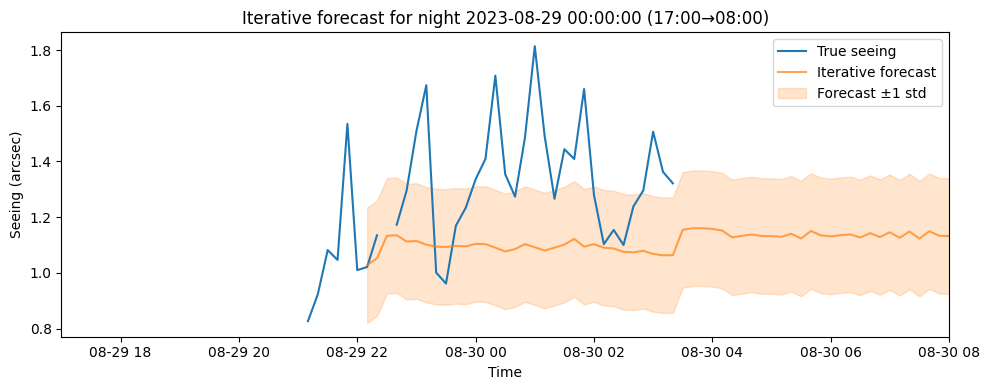

In [71]:
# Full-night view: 17:00 → 08:00
sample_night_date = pd.to_datetime(sample_night)
start = sample_night_date + pd.Timedelta(hours=17)
end = sample_night_date + pd.Timedelta(days=1, hours=8)
full_idx = pd.date_range(start, end, freq='10min')

# True seeing from the raw night slice
true_full = df_sorted.loc[start:end, 'Seeing'].reindex(full_idx)

y_true_iter = np.exp(true_full)

y_pred_iter = pd.Series(np.exp(iterative_preds), index=full_idx)

mask = y_true_iter.notna() & y_pred_iter.notna()
residuals_iter = (y_true_iter[mask] - y_pred_iter[mask])
err_std_iter = residuals_iter.std()

plt.figure(figsize=(10, 4))
plt.plot(full_idx, y_true_iter, label='True seeing')
plt.plot(full_idx, y_pred_iter, label='Iterative forecast', alpha=0.7)

plt.fill_between(
    full_idx,
    (y_pred_iter - err_std_iter),
    (y_pred_iter + err_std_iter),
    where=y_pred_iter.notna(),
    interpolate=True,
    color='C1',
    alpha=0.2,
    label='Forecast ±1 std'
)

plt.xlim(start, end)
plt.title(f'Iterative forecast for night {sample_night} (17:00→08:00)')
plt.xlabel('Time')
plt.ylabel('Seeing (arcsec)')
plt.legend()
plt.tight_layout()
plt.show()